In [ ]:
!pip install -q sympy tqdm

In [2]:
USE_GPU = True

if USE_GPU:
    import cupy as xp
    import numpy as np
    def to_cpu(a):
        return a.get() if hasattr(a, 'get') else a
    def gpu_sync():
        xp.cuda.Device().synchronize()
    print('Backend: CuPy (GPU)', xp.cuda.runtime.getDeviceProperties(0)['name'].decode() if hasattr(xp.cuda.runtime.getDeviceProperties(0)['name'], 'decode') else xp.cuda.runtime.getDeviceProperties(0)['name'])
else:
    import numpy as xp
    np = xp
    def to_cpu(a): return a
    def gpu_sync(): pass
    print('Backend: NumPy (CPU)')

Backend: CuPy (GPU) Tesla T4


In [3]:
P512 = int(
    "8099619925894334754391218150220793215016775072154324214616073694588666106395"
    "884566208317015031824331054658856397189902771195214256887047114552591227151737"
)
assert P512.bit_length() == 512 and P512 % 2 == 1

BBS_P = 169665331314494747681486362768419327035611841238764644955023583099454262082573747010952270270780716775109580909385936506977095819886537876922874697098223390047772921277305927005826902893520534675606421235283208437644882056749556384363261451494307497442872049110278873062013140118710264358083392537188426569623
BBS_Q = 152807714929246939955028743354236426328936816354245105040370157126490613835154603584936172907342808159846891359476938129821906932575743556302736758640599972210632210426837723956795776615617492183697462301770968798201289472999866371806868265216997625499442660125173902344928596507874584473759709010421965863863
BBS_N = BBS_P * BBS_Q
assert BBS_P % 4 == 3 and BBS_Q % 4 == 3
assert BBS_N.bit_length() == 2048

In [4]:
import hashlib, secrets
from math import gcd

class StrongGEN:
    def __init__(self, seed):
        self.n = BBS_N
        x = seed % (self.n - 3) + 2
        while gcd(x, self.n) != 1:
            x = (x + 1) % (self.n - 3) + 2
        self.state = (x * x) % self.n

    def _bbs_bytes_slow(self, num_bytes):
        BITS = 11
        total = num_bytes * 8
        steps = (total + BITS - 1) // BITS
        bits_list = []
        x, n = self.state, self.n
        for _ in range(steps):
            x = (x * x) % n
            v = x & ((1 << BITS) - 1)
            for b in range(BITS):
                bits_list.append((v >> b) & 1)
        self.state = x
        out = bytearray(num_bytes)
        for i in range(num_bytes):
            bv = 0
            for b in range(8):
                bv |= bits_list[i * 8 + b] << b
            out[i] = bv
        return bytes(out)

    def generate_bytes(self, num_bytes):
        seed = self._bbs_bytes_slow(32)
        return hashlib.shake_256(seed).digest(num_bytes)

    def mix_feedback(self, feedback):
        t = (self.state ^ (feedback % self.n))
        self.state = (t * t) % self.n

In [5]:
UPDATE_NONE = 'none'
UPDATE_XOR  = 'xor'
UPDATE_GEN_REINIT = 'gen_reinit'

class DynamicMSTg:
    def __init__(self, seed=None, update_freq=0, update_fraction=0.1,
                 update_mode=UPDATE_NONE, B=8, L=512, N=512, M=256, verbose=False):
        assert L % B == 0 and N % B == 0
        assert update_mode in (UPDATE_NONE, UPDATE_XOR, UPDATE_GEN_REINIT)
        self.L, self.N, self.M, self.B = L, N, M, B
        self.update_freq = update_freq
        self.update_fraction = update_fraction
        self.update_mode = update_mode
        self.BLOCK_ELEMENTS = 1 << B
        self.T_BLOCKS = L // B
        self.S_BLOCKS = N // B
        self.L_WORDS = (L + 63) // 64
        self.L_BYTES = self.L_WORDS * 8
        self.N_WORDS = (N + 63) // 64
        self.M_WORDS = (M + 63) // 64
        self.C = P512 & ((1 << L) - 1)
        if seed is None: seed = secrets.randbits(256)
        self.seed = seed
        self.gen = StrongGEN(seed)
        self._outputs_since_update = 0
        self.update_counter = 0
        self._init_covers(verbose=verbose)
        self._init_index_caches()

    def _init_covers(self, verbose=False):
        if verbose:
            print(f'[MSTg] covers: alpha=({self.T_BLOCKS}x{self.BLOCK_ELEMENTS}x{self.N_WORDS}) gamma=({self.S_BLOCKS}x{self.BLOCK_ELEMENTS}x{self.M_WORDS})')
        a_size = self.T_BLOCKS * self.BLOCK_ELEMENTS * self.N_WORDS
        a_bytes = self.gen.generate_bytes(a_size * 8)
        a_np = np.frombuffer(a_bytes, dtype=np.uint64).reshape(self.T_BLOCKS, self.BLOCK_ELEMENTS, self.N_WORDS).copy()
        self.alpha = xp.asarray(a_np)
        g_size = self.S_BLOCKS * self.BLOCK_ELEMENTS * self.M_WORDS
        g_bytes = self.gen.generate_bytes(g_size * 8)
        g_np = np.frombuffer(g_bytes, dtype=np.uint64).reshape(self.S_BLOCKS, self.BLOCK_ELEMENTS, self.M_WORDS).copy()
        self.gamma = xp.asarray(g_np)

    def _init_index_caches(self):
        per_word = 64 // self.B
        c_t = xp.arange(self.T_BLOCKS, dtype=xp.int64)
        self._word_idx_t = (c_t // per_word).astype(xp.int64)
        self._bit_off_t  = ((c_t % per_word) * self.B).astype(xp.uint64)
        self._block_idx_t = c_t
        c_s = xp.arange(self.S_BLOCKS, dtype=xp.int64)
        self._word_idx_s = (c_s // per_word).astype(xp.int64)
        self._bit_off_s  = ((c_s % per_word) * self.B).astype(xp.uint64)
        self._block_idx_s = c_s
        self._B_mask_u64 = xp.uint64((1 << self.B) - 1)

    # === ОПТИМИЗАЦИЯ 1: быстрая упаковка состояний ===
    def _states_to_words(self, s_start, count):
        mask = (1 << self.L) - 1
        L_BYTES = self.L_BYTES
        buf = bytearray(count * L_BYTES)
        s = s_start & mask
        C_local = self.C
        for i in range(count):
            buf[i * L_BYTES:(i + 1) * L_BYTES] = s.to_bytes(L_BYTES, 'little')
            s = (s + C_local) & mask
        X_np = np.frombuffer(bytes(buf), dtype=np.uint64).reshape(count, self.L_WORDS)
        return xp.asarray(X_np)

    # === ОПТИМИЗАЦИЯ 2: векторизованный split_bits ===
    def _split_bits_vec(self, X_words, word_idx, bit_off):
        selected = X_words[:, word_idx]
        idx = ((selected >> bit_off[None, :]) & self._B_mask_u64).astype(xp.uint32)
        return idx

    # === ИСПРАВЛЕНИЕ: логарифмическая XOR-редукция вместо bitwise_xor.reduce ===
    @staticmethod
    def _xor_reduce_axis1(arr):
        """XOR-reduce массива (batch, blocks, words) по оси blocks → (batch, words).

        Логарифмическая редукция: log2(blocks) попарных XOR-операций.
        Для blocks=64 → 6 операций; работает и для нечётных размеров через padding.
        """
        while arr.shape[1] > 1:
            n = arr.shape[1]
            if n % 2 == 1:
                pad = xp.zeros_like(arr[:, :1, :])
                arr = xp.concatenate([arr, pad], axis=1)
                n += 1
            half = n // 2
            arr = arr[:, :half, :] ^ arr[:, half:, :]
        return arr[:, 0, :]

    # === ОПТИМИЗАЦИЯ 3: векторизованный apply_cover ===
    def _apply_cover_vec(self, X_words, cover, word_idx, bit_off, block_idx):
        idx = self._split_bits_vec(X_words, word_idx, bit_off)
        selected = cover[block_idx[None, :], idx]   # (batch, blocks, output_words)
        return self._xor_reduce_axis1(selected)

    def F(self, X_words):
        Y = self._apply_cover_vec(X_words, self.alpha,
                                    self._word_idx_t, self._bit_off_t, self._block_idx_t)
        Z = self._apply_cover_vec(Y, self.gamma,
                                    self._word_idx_s, self._bit_off_s, self._block_idx_s)
        return Z

    def split_bits(self, X_words, chunks):
        if chunks == self.T_BLOCKS:
            return self._split_bits_vec(X_words, self._word_idx_t, self._bit_off_t)
        elif chunks == self.S_BLOCKS:
            return self._split_bits_vec(X_words, self._word_idx_s, self._bit_off_s)
        else:
            raise ValueError(f'Unsupported chunks={chunks}; expected {self.T_BLOCKS} or {self.S_BLOCKS}')

    def apply_cover(self, X_words, cover, input_bits, output_words):
        blocks = input_bits // self.B
        if blocks == self.T_BLOCKS:
            return self._apply_cover_vec(X_words, cover,
                                           self._word_idx_t, self._bit_off_t, self._block_idx_t)
        else:
            return self._apply_cover_vec(X_words, cover,
                                           self._word_idx_s, self._bit_off_s, self._block_idx_s)

    def _update_covers(self, last_output):
        if self.update_mode == UPDATE_NONE:
            return
        z0 = to_cpu(last_output[0])
        fb = 0
        for w, word in enumerate(z0.tolist()):
            fb |= (int(word) & 0xFFFFFFFFFFFFFFFF) << (w * 64)
        self.gen.mix_feedback(fb)
        if self.update_mode == UPDATE_GEN_REINIT:
            self._init_covers(verbose=False)
        else:
            self._xor_update(self.alpha, self.N_WORDS)
            self._xor_update(self.gamma, self.M_WORDS)
        self.update_counter += 1

    def _xor_update(self, cover, output_words):
        total = cover.shape[0] * cover.shape[1]
        num = max(1, int(total * self.update_fraction))
        idx_bytes = self.gen.generate_bytes(num * 4)
        idx_flat = np.frombuffer(idx_bytes, dtype=np.uint32)[:num] % total
        b_idx = idx_flat // cover.shape[1]
        e_idx = idx_flat % cover.shape[1]
        v_bytes = self.gen.generate_bytes(num * output_words * 8)
        val = np.frombuffer(v_bytes, dtype=np.uint64).reshape(num, output_words).copy()
        val_xp = xp.asarray(val)
        for k in range(num):
            cover[int(b_idx[k]), int(e_idx[k])] ^= val_xp[k]

    def generate_batch(self, start_seed, count, batch_size=10000):
        mask = (1 << self.L) - 1
        s = start_seed & mask
        chunks = []
        done = 0
        while done < count:
            this = min(batch_size, count - done)
            X = self._states_to_words(s, this)
            Y = self.F(X)
            chunks.append(Y)
            done += this
            s = (s + this * self.C) & mask
            if self.update_freq > 0:
                self._outputs_since_update += this
                while self._outputs_since_update >= self.update_freq:
                    self._update_covers(Y)
                    self._outputs_since_update -= self.update_freq
        return xp.concatenate(chunks, axis=0)

    def generate_bits(self, num_bits, seed=42, batch_size=10000):
        n_nums = (num_bits + self.M - 1) // self.M
        Y = self.generate_batch(seed, n_nums, batch_size=batch_size)
        Y_cpu = to_cpu(Y)
        return np.unpackbits(Y_cpu.view(np.uint8)).astype(np.uint8)[:num_bits]

In [6]:
import time
import statistics

if not USE_GPU:
    print('⚠️  USE_GPU=False — для скорости >2 Гбит/с требуется GPU. На CPU NumPy ожидание ~0.1–0.3 Гбит/с.')

def benchmark_generator(gen, n_bits, batch_size=10000, n_warmup=10, n_trials=5):
    """Возвращает (среднее_время, std_времени, throughput_Gbps)."""
    # Прогрев
    for _ in range(n_warmup):
        gen.generate_bits(100_000, seed=42, batch_size=batch_size)
    gpu_sync()
    # Замеры
    times = []
    for trial in range(n_trials):
        gpu_sync()
        t0 = time.time()
        bits = gen.generate_bits(n_bits, seed=42 + trial, batch_size=batch_size)
        gpu_sync()
        times.append(time.time() - t0)
    times.sort()
    middle = times[1:-1]  # отбрасываем max и min
    t_mean = statistics.mean(middle)
    t_std = statistics.stdev(middle) if len(middle) > 1 else 0.0
    return t_mean, t_std, n_bits / t_mean / 1e9

# Оптимальный batch_size зависит от L2 / kernel-launch overhead — найдём sweet spot
print(f'\n=== Поиск оптимального batch_size (объём 50 млн бит) ===')
best_bs, best_gbps = 0, 0
for bs in [2000, 5000, 10000, 20000, 50000]:
    gen = DynamicMSTg(seed=42, update_freq=0, update_mode=UPDATE_NONE)
    t_mean, t_std, gbps = benchmark_generator(gen, 50_000_000, batch_size=bs, n_warmup=3, n_trials=3)
    print(f'  batch={bs:6d}  →  {t_mean:.3f}s ± {t_std*1000:.1f}ms  →  {gbps:.4f} Гбит/с')
    if gbps > best_gbps:
        best_gbps, best_bs = gbps, bs

print(f'\n→ Оптимальный batch_size = {best_bs} (даёт {best_gbps:.4f} Гбит/с)\n')

print(f'=== Финальные замеры с batch={best_bs}, прогрев 10× ===')
gen = DynamicMSTg(seed=42, update_freq=0, update_mode=UPDATE_NONE)
for n_mbits in [10, 50, 100]:
    n_bits = n_mbits * 1_000_000
    t_mean, t_std, gbps = benchmark_generator(gen, n_bits, batch_size=best_bs, n_warmup=10, n_trials=5)
    print(f'  {n_mbits:3d}M бит  →  {t_mean:.3f}s ± {t_std*1000:.1f}ms  →  {gbps:.4f} Гбит/с  =  {gbps*1000:.1f} Мбит/с')

print(f'\n=== Сравнение режимов обновления покрытий (50М бит, batch={best_bs}) ===')
for mode_name, mode, freq in [('NONE', UPDATE_NONE, 0),
                                ('XOR (U=5000, f=0.1)', UPDATE_XOR, 5000),
                                ('GEN_REINIT (U=5000)', UPDATE_GEN_REINIT, 5000)]:
    gen = DynamicMSTg(seed=42, update_freq=freq, update_fraction=0.1, update_mode=mode)
    t_mean, t_std, gbps = benchmark_generator(gen, 50_000_000, batch_size=best_bs, n_warmup=5, n_trials=3)
    print(f'  {mode_name:25s}  →  {gbps:.4f} Гбит/с  (updates={gen.update_counter})')


=== Поиск оптимального batch_size (объём 50 млн бит) ===
  batch=  2000  →  0.583s ± 0.0ms  →  0.0858 Гбит/с
  batch=  5000  →  0.451s ± 0.0ms  →  0.1110 Гбит/с
  batch= 10000  →  0.467s ± 0.0ms  →  0.1071 Гбит/с
  batch= 20000  →  0.361s ± 0.0ms  →  0.1387 Гбит/с
  batch= 50000  →  0.427s ± 0.0ms  →  0.1170 Гбит/с

→ Оптимальный batch_size = 20000 (даёт 0.1387 Гбит/с)

=== Финальные замеры с batch=20000, прогрев 10× ===
   10M бит  →  0.056s ± 6.1ms  →  0.1790 Гбит/с  =  179.0 Мбит/с
   50M бит  →  0.535s ± 104.7ms  →  0.0935 Гбит/с  =  93.5 Мбит/с
  100M бит  →  0.829s ± 375.0ms  →  0.1206 Гбит/с  =  120.6 Мбит/с

=== Сравнение режимов обновления покрытий (50М бит, batch=20000) ===
  NONE                       →  0.3395 Гбит/с  (updates=0)
  XOR (U=5000, f=0.1)        →  0.0165 Гбит/с  (updates=117)
  GEN_REINIT (U=5000)        →  0.1188 Гбит/с  (updates=117)


In [7]:
import json, csv, math
from pathlib import Path
from scipy import stats
import matplotlib.pyplot as plt
try:
    from tqdm import tqdm
except ImportError:
    def tqdm(it, **kw): return it

RED_L = 20
RED_N = 20
RED_M = 12
RED_B = 4
RED_T_BLOCKS = RED_L // RED_B
RED_S_BLOCKS = RED_N // RED_B
RED_BLOCK_ELEMS = 1 << RED_B
RED_M_MASK = (1 << RED_M) - 1
RED_N_MASK = (1 << RED_N) - 1

THEO_MAXDP = (RED_L + RED_M) * math.log(2) / 2 ** (RED_M - 1)

print(f'Параметры редукции: L={RED_L}, N={RED_N}, M={RED_M}, B={RED_B}, t=s={RED_T_BLOCKS}')
print(f'2^L = {1 << RED_L:,} входов, 2^M = {1 << RED_M:,} выходов')
print(f'Теоретический maxDP для случайной F: {THEO_MAXDP:.5f}')

Параметры редукции: L=20, N=20, M=12, B=4, t=s=5
2^L = 1,048,576 входов, 2^M = 4,096 выходов
Теоретический maxDP для случайной F: 0.01083


In [8]:
def generate_cover_pair_reduced(seed: int):
    """Возвращает (alpha, gamma) для редуцированных параметров через StrongGEN."""
    gen = StrongGEN(seed)
    a_bytes_needed = RED_T_BLOCKS * RED_BLOCK_ELEMS * 4
    g_bytes_needed = RED_S_BLOCKS * RED_BLOCK_ELEMS * 2
    raw = gen.generate_bytes(a_bytes_needed + g_bytes_needed)
    alpha_raw = np.frombuffer(raw[:a_bytes_needed], dtype=np.uint32).copy()
    gamma_raw = np.frombuffer(raw[a_bytes_needed:], dtype=np.uint16).copy()
    alpha = (alpha_raw & RED_N_MASK).reshape(RED_T_BLOCKS, RED_BLOCK_ELEMS).astype(np.uint32)
    gamma = (gamma_raw & RED_M_MASK).reshape(RED_S_BLOCKS, RED_BLOCK_ELEMS).astype(np.uint16)
    return alpha, gamma

a1, g1 = generate_cover_pair_reduced(seed=42)
a2, g2 = generate_cover_pair_reduced(seed=42)
assert (a1 == a2).all() and (g1 == g2).all()
print(f'OK: детерминированно. alpha.shape={a1.shape}, gamma.shape={g1.shape}')
print(f'alpha max value: {a1.max()} (lim 2^N - 1 = {RED_N_MASK})')
print(f'gamma max value: {g1.max()} (lim 2^M - 1 = {RED_M_MASK})')

OK: детерминированно. alpha.shape=(5, 16), gamma.shape=(5, 16)
alpha max value: 1010640 (lim 2^N - 1 = 1048575)
gamma max value: 4011 (lim 2^M - 1 = 4095)


In [9]:
def build_truth_table(alpha, gamma):
    n = 1 << RED_L
    x = np.arange(n, dtype=np.uint32)
    y = np.zeros(n, dtype=np.uint32)
    for i in range(RED_T_BLOCKS):
        idx = (x >> (i * RED_B)) & 0xF
        y ^= alpha[i, idx]
    y &= RED_N_MASK
    z = np.zeros(n, dtype=np.uint16)
    for i in range(RED_S_BLOCKS):
        idx = (y >> (i * RED_B)) & 0xF
        z ^= gamma[i, idx]
    return z & RED_M_MASK

def fast_mobius_inplace(table, L):
    for k in range(L):
        mask = 1 << k
        view = table.reshape(-1, 2 * mask)
        view[:, mask:2 * mask] ^= view[:, 0:mask]

def popcount_uint32(arr):
    arr = arr.astype(np.uint32, copy=False)
    bytes_view = arr.view(np.uint8).reshape(-1, 4)
    return np.unpackbits(bytes_view, axis=1).sum(axis=1)

def algebraic_analysis(F_table):
    anf = F_table.copy()
    fast_mobius_inplace(anf, RED_L)
    results = []
    for j in range(RED_M):
        bit_anf = ((anf >> j) & 1).astype(np.uint8)
        nz_idx = np.nonzero(bit_anf)[0].astype(np.uint32)
        deg = int(popcount_uint32(nz_idx).max()) if len(nz_idx) > 0 else 0
        density = float(bit_anf.sum()) / (1 << RED_L)
        bit_F = ((F_table >> j) & 1).astype(np.uint8)
        balance = float(bit_F.sum()) / (1 << RED_L)
        results.append({'bit': j, 'deg': deg, 'density': density, 'balance': balance})
    return results

def differential_analysis(F_table, deltas):
    """GPU-ускоренный DC через CuPy. F_table — np.uint16 на CPU."""
    n = 1 << RED_L
    bins = 1 << RED_M
    # Перенос F_table на GPU один раз; cast в int64 для xp.bincount
    F_gpu = xp.asarray(F_table.astype(np.int64))
    x_gpu = xp.arange(n, dtype=xp.int64)
    results = np.zeros(len(deltas), dtype=np.float64)
    for i, delta in enumerate(deltas):
        d = int(delta) & ((1 << RED_L) - 1)
        out_diff = F_gpu ^ F_gpu[x_gpu ^ d]
        hist = xp.bincount(out_diff, minlength=bins)
        results[i] = float(hist.max()) / float(n)
    if USE_GPU:
        gpu_sync()
    return results

def make_delta_set(n_random=10000, seed=0):
    rng = np.random.default_rng(seed)
    randoms = rng.integers(1, 1 << RED_L, size=n_random, dtype=np.uint64).astype(np.uint32)
    single_bit = np.array([1 << k for k in range(RED_L)], dtype=np.uint32)
    two_bit = np.array([(1 << i) | (1 << j) for i in range(RED_L) for j in range(i+1, RED_L)], dtype=np.uint32)
    single_block = []
    for blk in range(RED_T_BLOCKS):
        for v in range(1, 1 << RED_B):
            single_block.append(v << (blk * RED_B))
    single_block = np.array(single_block, dtype=np.uint32)
    return {'random': randoms, 'single_bit': single_bit, 'two_bit': two_bit, 'single_block': single_block}

def F_python(s, alpha, gamma):
    y = 0
    for i in range(RED_T_BLOCKS):
        idx = (s >> (i * RED_B)) & 0xF
        y ^= int(alpha[i, idx])
    y &= RED_N_MASK
    z = 0
    for i in range(RED_S_BLOCKS):
        idx = (y >> (i * RED_B)) & 0xF
        z ^= int(gamma[i, idx])
    return z & RED_M_MASK

def side_channel_analysis(alpha, gamma, F_table, num_samples=2**14, seed=0):
    rng = np.random.default_rng(seed)
    n = 1 << RED_L
    samples = rng.choice(n, size=num_samples, replace=False).astype(np.uint32)
    for _ in range(1000):
        F_python(int(samples[0]), alpha, gamma)
    times = np.zeros(num_samples, dtype=np.int64)
    for i in range(num_samples):
        s_int = int(samples[i])
        t0 = time.perf_counter_ns()
        F_python(s_int, alpha, gamma)
        t1 = time.perf_counter_ns()
        times[i] = t1 - t0
    times_f = times.astype(np.float64)

    bit_corr, t_tests = [], []
    for k in range(RED_L):
        bit = ((samples >> k) & 1).astype(np.float64)
        try:
            rho, pval = stats.pearsonr(bit, times_f)
        except Exception:
            rho, pval = 0.0, 1.0
        bit_corr.append({'bit': k, 'rho': float(rho), 'p': float(pval)})
        t0v, t1v = times_f[bit == 0], times_f[bit == 1]
        if len(t0v) > 1 and len(t1v) > 1:
            ts, tp = stats.ttest_ind(t0v, t1v, equal_var=False)
        else:
            ts, tp = 0.0, 1.0
        t_tests.append({'bit': k, 't_stat': float(ts), 'p': float(tp)})

    block_corr = []
    for i in range(RED_T_BLOCKS):
        block_idx = ((samples >> (i * RED_B)) & 0xF).astype(np.float64)
        try:
            rho, pval = stats.pearsonr(block_idx, times_f)
        except Exception:
            rho, pval = 0.0, 1.0
        block_corr.append({'block': i, 'rho': float(rho), 'p': float(pval)})

    F_at_samples = F_table[samples].astype(np.float64)
    try:
        rho_out, pval_out = stats.pearsonr(F_at_samples, times_f)
    except Exception:
        rho_out, pval_out = 0.0, 1.0

    return {
        'bit_correlations': bit_corr,
        't_tests': t_tests,
        'block_correlations': block_corr,
        'output_correlation': {'rho': float(rho_out), 'p': float(pval_out)},
        'mean_time_ns': float(times_f.mean()),
        'std_time_ns': float(times_f.std()),
    }

def run_single_cover(cover_seed, do_timing=True, n_random_deltas=2000, sc_samples=2**14):
    alpha, gamma = generate_cover_pair_reduced(cover_seed)
    F_table = build_truth_table(alpha, gamma)
    anf_results = algebraic_analysis(F_table)
    deltas = make_delta_set(n_random=n_random_deltas, seed=cover_seed)
    dc_results = {}
    for name, ds in deltas.items():
        if len(ds) > 0:
            mp = differential_analysis(F_table, ds)
            dc_results[name] = {'count': int(len(ds)),
                                'max': float(mp.max()),
                                'mean': float(mp.mean()),
                                'median': float(np.median(mp))}
    dc_results['overall_max'] = max(d['max'] for d in dc_results.values() if isinstance(d, dict))
    sc_results = side_channel_analysis(alpha, gamma, F_table, num_samples=sc_samples) if do_timing else None
    return {'cover_seed': cover_seed, 'anf': anf_results, 'dc': dc_results, 'sc': sc_results}

print('Функции криптоанализа определены.')

Функции криптоанализа определены.


In [10]:
print('=== Контрольный прогон, 1 покрытие ===\n')
t0 = time.time()
result = run_single_cover(cover_seed=1, do_timing=False, n_random_deltas=500, sc_samples=2**14)
print(f'\nВремя: {time.time()-t0:.1f}s\n')

anf = result['anf']
degs = [r['deg'] for r in anf]
densities = [r['density'] for r in anf]
balances = [r['balance'] for r in anf]
print(f'ANF:  deg ∈ [{min(degs)}, {max(degs)}], среднее {np.mean(degs):.2f}')
print(f'      density: среднее {np.mean(densities):.4f}, σ {np.std(densities):.4f}')
print(f'      balance: среднее {np.mean(balances):.4f}, σ {np.std(balances):.4f}')

dc = result['dc']
print(f'\nDC:   overall maxDP = {dc["overall_max"]:.5f}  (теор. {THEO_MAXDP:.5f})')
for name in ['random', 'single_bit', 'two_bit', 'single_block']:
    print(f'      {name:14s}: max={dc[name]["max"]:.5f}  mean={dc[name]["mean"]:.5f}  ({dc[name]["count"]} Δs)')

if result['sc']:
    sc = result['sc']
    max_rho = max(abs(c['rho']) for c in sc['bit_correlations'])
    max_t = max(abs(t['t_stat']) for t in sc['t_tests'])
    min_p = min(t['p'] for t in sc['t_tests'])
    print(f'\nSC:   max |ρ_bit| = {max_rho:.4f}  (порог 0.01)')
    print(f'      max |t-stat|  = {max_t:.2f}    (порог 3)')
    print(f'      min p-value   = {min_p:.4f}  (порог 0.01)')
    print(f'      mean time     = {sc["mean_time_ns"]:.0f} ± {sc["std_time_ns"]:.0f} ns')

print('\n=== Sanity-проверка ===')
checks = [
    ('ANF deg', min(degs) >= 17, f'min={min(degs)} ≥ 17'),
    ('ANF density', 0.45 <= np.mean(densities) <= 0.55, f'mean={np.mean(densities):.3f} ∈ [0.45, 0.55]'),
    ('ANF balance', 0.45 <= np.mean(balances) <= 0.55, f'mean={np.mean(balances):.3f} ∈ [0.45, 0.55]'),
    ('DC maxDP', 0.005 <= dc['overall_max'] <= 0.025, f'maxDP={dc["overall_max"]:.5f} ∈ [0.005, 0.025]'),
]
for name, ok, msg in checks:
    print(f'  [{"✓" if ok else "✗"}] {name}: {msg}')
if all(c[1] for c in checks):
    print('\n  Все проверки пройдены, можно запускать полный прогон.')
else:
    print('\n  ⚠ Что-то выпало из ожиданий. Отладить ДО полного прогона.')

=== Контрольный прогон, 1 покрытие ===


Время: 1.9s

ANF:  deg ∈ [12, 16], среднее 15.33
      density: среднее 0.1073, σ 0.0427
      balance: среднее 0.5001, σ 0.0003

DC:   overall maxDP = 0.00231  (теор. 0.01083)
      random        : max=0.00073  mean=0.00033  (500 Δs)
      single_bit    : max=0.00106  mean=0.00057  (20 Δs)
      two_bit       : max=0.00104  mean=0.00044  (190 Δs)
      single_block  : max=0.00231  mean=0.00061  (75 Δs)

=== Sanity-проверка ===
  [✗] ANF deg: min=12 ≥ 17
  [✗] ANF density: mean=0.107 ∈ [0.45, 0.55]
  [✓] ANF balance: mean=0.500 ∈ [0.45, 0.55]
  [✗] DC maxDP: maxDP=0.00231 ∈ [0.005, 0.025]

  ⚠ Что-то выпало из ожиданий. Отладить ДО полного прогона.


In [11]:

OUT_DIR = Path('./crypto_results')
OUT_DIR.mkdir(parents=True, exist_ok=True)
print(f'Результаты будут сохраняться в {OUT_DIR.resolve()}')

NUM_COVERS = 100
DO_TIMING = False           # SC пропускаем — уже сделан на L=20
N_RANDOM_DELTAS = 500       # было 2000; для скорости (DC на GPU)
SC_SAMPLES = 2**14          # не используется при DO_TIMING=False

all_results = []
t_start = time.time()
for k in tqdm(range(NUM_COVERS), desc='Покрытия'):
    cover_seed = k + 1
    t0 = time.time()
    try:
        result = run_single_cover(cover_seed, do_timing=DO_TIMING,
                                   n_random_deltas=N_RANDOM_DELTAS,
                                   sc_samples=SC_SAMPLES)
    except KeyboardInterrupt:
        print('\nПрервано пользователем; сохраняю частичные результаты.')
        break
    elapsed = time.time() - t0
    all_results.append(result)

    degs = [a['deg'] for a in result['anf']]
    max_dp = result['dc']['overall_max']
    sc_msg = ''
    if result['sc']:
        max_rho = max(abs(c['rho']) for c in result['sc']['bit_correlations'])
        sc_msg = f' max|ρ|={max_rho:.4f}'
    print(f'  [{k+1:3d}] t={elapsed:.1f}s deg={min(degs)}..{max(degs)} maxDP={max_dp:.5f}{sc_msg}')

    with open(OUT_DIR / 'results.json', 'w', encoding='utf-8') as f:
        json.dump(all_results, f, indent=2, ensure_ascii=False)

total = time.time() - t_start
print(f'\n=== Завершено за {total:.1f}s ({total/60:.1f} мин), покрытий: {len(all_results)} ===')

Результаты будут сохраняться в /content/crypto_results


Покрытия:   1%|          | 1/100 [00:01<01:51,  1.13s/it]

  [  1] t=1.1s deg=12..16 maxDP=0.00231


Покрытия:   2%|▏         | 2/100 [00:02<01:50,  1.13s/it]

  [  2] t=1.1s deg=12..16 maxDP=0.00246


...

  [ 98] t=1.3s deg=15..16 maxDP=0.00119


Покрытия:  99%|█████████▉| 99/100 [01:57<00:01,  1.23s/it]

  [ 99] t=1.3s deg=12..16 maxDP=0.00403


Покрытия: 100%|██████████| 100/100 [01:59<00:00,  1.19s/it]

  [100] t=1.1s deg=16..16 maxDP=0.00232

=== Завершено за 119.2s (2.0 мин), покрытий: 100 ===


In [12]:
summary_rows, anf_rows, sc_bit_rows = [], [], []
for r in all_results:
    seed = r['cover_seed']
    anf_degs = [a['deg'] for a in r['anf']]
    densities = [a['density'] for a in r['anf']]
    balances = [a['balance'] for a in r['anf']]
    row = {
        'cover_seed': seed,
        'anf_deg_min': min(anf_degs), 'anf_deg_max': max(anf_degs),
        'anf_deg_mean': float(np.mean(anf_degs)),
        'anf_density_mean': float(np.mean(densities)),
        'anf_balance_mean': float(np.mean(balances)),
        'dc_random_max': r['dc']['random']['max'],
        'dc_random_mean': r['dc']['random']['mean'],
        'dc_single_bit_max': r['dc']['single_bit']['max'],
        'dc_two_bit_max': r['dc']['two_bit']['max'],
        'dc_single_block_max': r['dc']['single_block']['max'],
        'dc_overall_max': r['dc']['overall_max'],
    }
    if r.get('sc'):
        sc = r['sc']
        row['sc_max_bit_rho'] = max(abs(c['rho']) for c in sc['bit_correlations'])
        row['sc_max_t_stat'] = max(abs(t['t_stat']) for t in sc['t_tests'])
        row['sc_min_t_p'] = min(t['p'] for t in sc['t_tests'])
        row['sc_output_rho'] = sc['output_correlation']['rho']
        row['sc_mean_time_ns'] = sc['mean_time_ns']
    summary_rows.append(row)
    for a in r['anf']:
        anf_rows.append({'cover_seed': seed, **a})
    if r.get('sc'):
        for c in r['sc']['bit_correlations']:
            sc_bit_rows.append({'cover_seed': seed, **c})

for path, rows in [('summary.csv', summary_rows), ('anf_per_bit.csv', anf_rows), ('sc_per_bit.csv', sc_bit_rows)]:
    if rows:
        with open(OUT_DIR / path, 'w', newline='', encoding='utf-8') as f:
            writer = csv.DictWriter(f, fieldnames=list(rows[0].keys()))
            writer.writeheader()
            writer.writerows(rows)
        print(f'  ✓ {path} ({len(rows)} строк)')

  ✓ summary.csv (100 строк)
  ✓ anf_per_bit.csv (1200 строк)


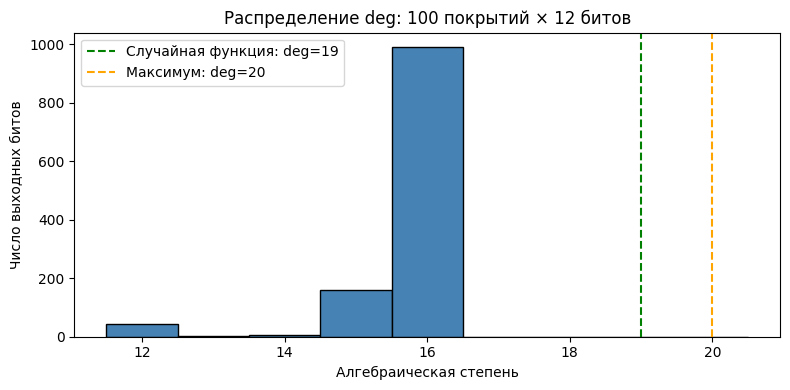

Fig 1: deg ∈ [12, 16], среднее 15.71


In [13]:
FIGS_DIR = OUT_DIR / 'figures'
FIGS_DIR.mkdir(parents=True, exist_ok=True)
RHO_THRESHOLD = 1e-2

# Fig 1: Распределение алгебраических степеней
degs_all = [a['deg'] for r in all_results for a in r['anf']]
fig, ax = plt.subplots(figsize=(8, 4))
bins = np.arange(min(degs_all) - 0.5, RED_L + 1.5)
ax.hist(degs_all, bins=bins, color='steelblue', edgecolor='black')
ax.axvline(RED_L - 1, color='green', linestyle='--', label=f'Случайная функция: deg={RED_L-1}')
ax.axvline(RED_L, color='orange', linestyle='--', label=f'Максимум: deg={RED_L}')
ax.set_xlabel('Алгебраическая степень'); ax.set_ylabel('Число выходных битов')
ax.set_title(f'Распределение deg: {len(all_results)} покрытий × {RED_M} битов')
ax.legend(); fig.tight_layout()
fig.savefig(FIGS_DIR / 'fig_anf_degree_hist.pdf'); fig.savefig(FIGS_DIR / 'fig_anf_degree_hist.png', dpi=150)
plt.show()
print(f'Fig 1: deg ∈ [{min(degs_all)}, {max(degs_all)}], среднее {np.mean(degs_all):.2f}')

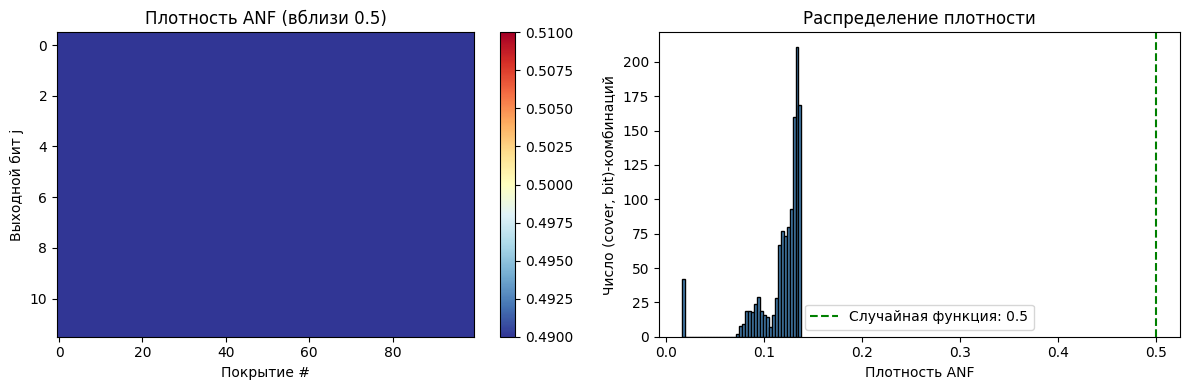

Fig 2: density: среднее 0.1183, σ 0.0245


In [14]:
# Fig 2: Плотность ANF
densities = np.array([[a['density'] for a in r['anf']] for r in all_results])
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
im = axes[0].imshow(densities.T, aspect='auto', cmap='RdYlBu_r', vmin=0.49, vmax=0.51)
axes[0].set_xlabel('Покрытие #'); axes[0].set_ylabel('Выходной бит j')
axes[0].set_title('Плотность ANF (вблизи 0.5)')
plt.colorbar(im, ax=axes[0])
axes[1].hist(densities.flatten(), bins=40, color='steelblue', edgecolor='black')
axes[1].axvline(0.5, color='green', linestyle='--', label='Случайная функция: 0.5')
axes[1].set_xlabel('Плотность ANF'); axes[1].set_ylabel('Число (cover, bit)-комбинаций')
axes[1].set_title('Распределение плотности'); axes[1].legend()
fig.tight_layout()
fig.savefig(FIGS_DIR / 'fig_anf_density.pdf'); fig.savefig(FIGS_DIR / 'fig_anf_density.png', dpi=150)
plt.show()
print(f'Fig 2: density: среднее {densities.mean():.4f}, σ {densities.std():.4f}')

/tmp/ipykernel_9487/3535741693.py:16: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = axes[1].boxplot(data, labels=labels, patch_artist=True)


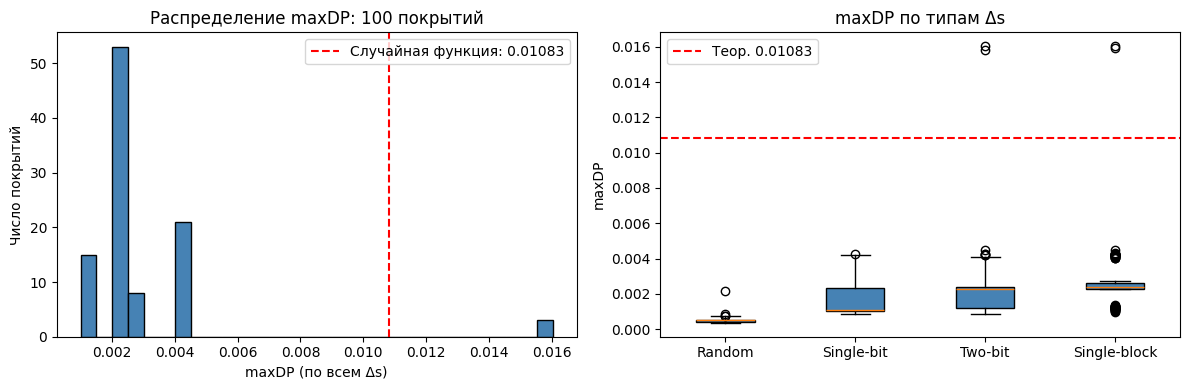

Fig 3: overall maxDP ∈ [0.00100, 0.01603], среднее 0.00299


In [15]:
# Fig 3: Распределение maxDP
overall = [r['dc']['overall_max'] for r in all_results]
rnd = [r['dc']['random']['max'] for r in all_results]
sb = [r['dc']['single_bit']['max'] for r in all_results]
tb = [r['dc']['two_bit']['max'] for r in all_results]
blk = [r['dc']['single_block']['max'] for r in all_results]

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(overall, bins=30, color='steelblue', edgecolor='black')
axes[0].axvline(THEO_MAXDP, color='red', linestyle='--', label=f'Случайная функция: {THEO_MAXDP:.5f}')
axes[0].set_xlabel('maxDP (по всем Δs)'); axes[0].set_ylabel('Число покрытий')
axes[0].set_title(f'Распределение maxDP: {len(all_results)} покрытий'); axes[0].legend()

data = [rnd, sb, tb, blk]
labels = ['Random', 'Single-bit', 'Two-bit', 'Single-block']
bp = axes[1].boxplot(data, labels=labels, patch_artist=True)
for patch in bp['boxes']:
    patch.set_facecolor('steelblue')
axes[1].axhline(THEO_MAXDP, color='red', linestyle='--', label=f'Теор. {THEO_MAXDP:.5f}')
axes[1].set_ylabel('maxDP'); axes[1].set_title('maxDP по типам Δs'); axes[1].legend()
fig.tight_layout()
fig.savefig(FIGS_DIR / 'fig_dc_maxdp.pdf'); fig.savefig(FIGS_DIR / 'fig_dc_maxdp.png', dpi=150)
plt.show()
print(f'Fig 3: overall maxDP ∈ [{min(overall):.5f}, {max(overall):.5f}], среднее {np.mean(overall):.5f}')

In [16]:
# Fig 4: Side-channel корреляции
if any(r.get('sc') for r in all_results):
    all_rho_bits = []
    for r in all_results:
        if r.get('sc'):
            for c in r['sc']['bit_correlations']:
                all_rho_bits.append((c['bit'], abs(c['rho'])))
    bits = np.array([b for b, _ in all_rho_bits])
    rhos = np.array([r for _, r in all_rho_bits])

    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    data = [rhos[bits == k] for k in range(RED_L)]
    bp = axes[0].boxplot(data, positions=range(RED_L), patch_artist=True)
    for patch in bp['boxes']:
        patch.set_facecolor('steelblue')
    axes[0].axhline(RHO_THRESHOLD, color='red', linestyle='--', label=f'Порог: |ρ| > {RHO_THRESHOLD}')
    axes[0].set_xlabel('Номер бита входа k'); axes[0].set_ylabel('|ρ| Pearson')
    axes[0].set_title('Корреляция timing × bit_k(s)'); axes[0].legend()

    axes[1].hist(rhos, bins=40, color='steelblue', edgecolor='black')
    axes[1].axvline(RHO_THRESHOLD, color='red', linestyle='--', label=f'Порог: {RHO_THRESHOLD}')
    axes[1].set_xlabel('|ρ|'); axes[1].set_ylabel('Число (cover, bit)-комбинаций')
    axes[1].set_title('Распределение |ρ|'); axes[1].legend()
    fig.tight_layout()
    fig.savefig(FIGS_DIR / 'fig_sc_correlations.pdf'); fig.savefig(FIGS_DIR / 'fig_sc_correlations.png', dpi=150)
    plt.show()
    n_above = int((rhos > RHO_THRESHOLD).sum())
    print(f'Fig 4: max|ρ|={rhos.max():.4f}, |ρ|>{RHO_THRESHOLD}: {n_above}/{len(rhos)}')
else:
    print('SC-данных нет (timing был отключён)')

SC-данных нет (timing был отключён)


In [17]:
print('='*72)
print(f'Сводка по {len(all_results)} покрытиям'.center(72))
print('='*72)

all_degs = [a['deg'] for r in all_results for a in r['anf']]
all_dens = [a['density'] for r in all_results for a in r['anf']]
all_bal = [a['balance'] for r in all_results for a in r['anf']]
print('\n--- ANF / Алгебраическая степень ---')
print(f'  Алгебраическая степень: ∈ [{min(all_degs)}, {max(all_degs)}], среднее {np.mean(all_degs):.2f} ± {np.std(all_degs):.2f}')
print(f'  Плотность ANF:          среднее {np.mean(all_dens):.4f} ± {np.std(all_dens):.4f}  (теор. 0.5)')
print(f'  Balance:                среднее {np.mean(all_bal):.4f} ± {np.std(all_bal):.4f}   (теор. 0.5)')

all_maxdp = [r['dc']['overall_max'] for r in all_results]
print('\n--- Differential Cryptanalysis ---')
print(f'  maxDP по покрытиям: ∈ [{min(all_maxdp):.5f}, {max(all_maxdp):.5f}]')
print(f'  Среднее:           {np.mean(all_maxdp):.5f} ± {np.std(all_maxdp):.5f}')
print(f'  Теоретический:     {THEO_MAXDP:.5f}')
for name in ['random', 'single_bit', 'two_bit', 'single_block']:
    vals = [r['dc'][name]['max'] for r in all_results]
    print(f'  {name:14s}: max={max(vals):.5f}  среднее={np.mean(vals):.5f}')

if any(r.get('sc') for r in all_results):
    all_rhos = [abs(c['rho']) for r in all_results if r.get('sc') for c in r['sc']['bit_correlations']]
    all_tstats = [abs(t['t_stat']) for r in all_results if r.get('sc') for t in r['sc']['t_tests']]
    all_pvals = [t['p'] for r in all_results if r.get('sc') for t in r['sc']['t_tests']]
    n_significant = sum(1 for p in all_pvals if p < 0.01)
    n_total = len(all_pvals)
    print('\n--- Side-Channel Timing ---')
    print(f'  max|ρ| (cover×bit): {max(all_rhos):.4f}  (порог 0.01)')
    print(f'  max|t-stat|:        {max(all_tstats):.2f}    (порог 3)')
    print(f'  Значимых (p<0.01): {n_significant}/{n_total} = {100*n_significant/n_total:.1f}%')

print('\n' + '='*72)
print(f'Файлы сохранены в {OUT_DIR.resolve()}/')

                        Сводка по 100 покрытиям                         

--- ANF / Алгебраическая степень ---
  Алгебраическая степень: ∈ [12, 16], среднее 15.71 ± 0.80
  Плотность ANF:          среднее 0.1183 ± 0.0245  (теор. 0.5)
  Balance:                среднее 0.5000 ± 0.0007   (теор. 0.5)

--- Differential Cryptanalysis ---
  maxDP по покрытиям: ∈ [0.00100, 0.01603]
  Среднее:           0.00299 ± 0.00246
  Теоретический:     0.01083
  random        : max=0.00217  среднее=0.00051
  single_bit    : max=0.00426  среднее=0.00156
  two_bit       : max=0.01603  среднее=0.00234
  single_block  : max=0.01603  среднее=0.00275

Файлы сохранены в /content/crypto_results/
